In [10]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np




In [11]:
img_height = 150
img_width = 150
batch_size = 32
epochs = 50
base_dir = "Box"


In [12]:
import os

valid_extensions = ['.jpg', '.jpeg', '.png']

def clean_folder(folder_path):
    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)
        for fname in os.listdir(class_path):
            if not any(fname.lower().endswith(ext) for ext in valid_extensions):
                print(f"⚠️ Removing invalid file: {fname}")
                os.remove(os.path.join(class_path, fname))

clean_folder("Box")


In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 20% for validation
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 187 images belonging to 2 classes.


Found 46 images belonging to 2 classes.


In [14]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')  # 2 classes: correct box, broken box
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


c:\Users\Jindal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,610 (18.42 MB)

 Trainable params: 4,828,610 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)


c:\Users\Jindal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 891ms/step - accuracy: 0.5398 - loss: 1.0154 - val_accuracy: 0.5652 - val_loss: 0.6891
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 524ms/step - accuracy: 0.5463 - loss: 0.6849 - val_accuracy: 0.5652 - val_loss: 0.6794
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 515ms/step - accuracy: 0.5814 - loss: 0.6775 - val_accuracy: 0.5652 - val_loss: 0.6817
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 522ms/step - accuracy: 0.5756 - loss: 0.6743 - val_accuracy: 0.5652 - val_loss: 0.6826
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 476ms/step - accuracy: 0.5759 - loss: 0.6666 - val_accuracy: 0.5652 - val_loss: 0.6789
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 522ms/step - accuracy: 0.6067 - loss: 0.6529 - val_accuracy: 0.5870 - val_loss: 0.6863
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 489ms/step - accuracy: 0.6495 - loss: 0.6229 - val_accuracy: 0.5435 - val_loss: 0.6820
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 542ms/step - accuracy: 0.6759 - loss: 0.6262 - val_accuracy: 0.5652 - val_loss:

In [12]:
val_generator.reset()
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step


In [13]:
print("\nClassification Report:")
print(classification_report(val_generator.classes, y_pred, target_names=list(val_generator.class_indices.keys())))



Classification Report:
              precision    recall  f1-score   support

  broken box       0.75      0.69      0.72        26
 correct box       0.64      0.70      0.67        20

    accuracy                           0.70        46
   macro avg       0.69      0.70      0.69        46
weighted avg       0.70      0.70      0.70        46



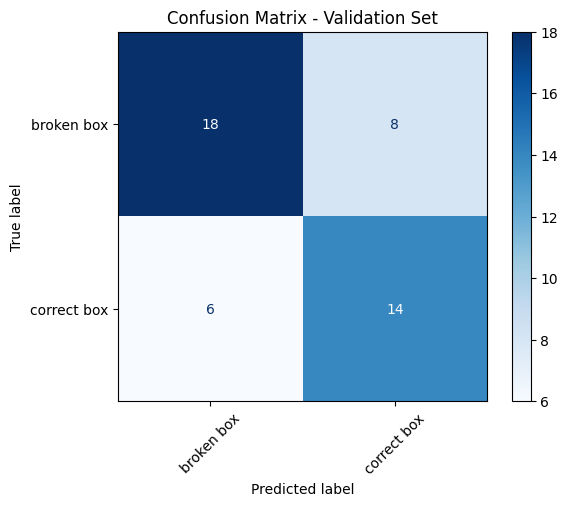

In [14]:
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Validation Set")
plt.show()


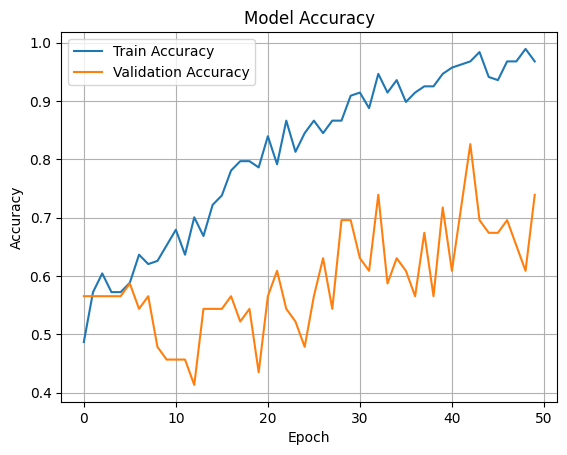

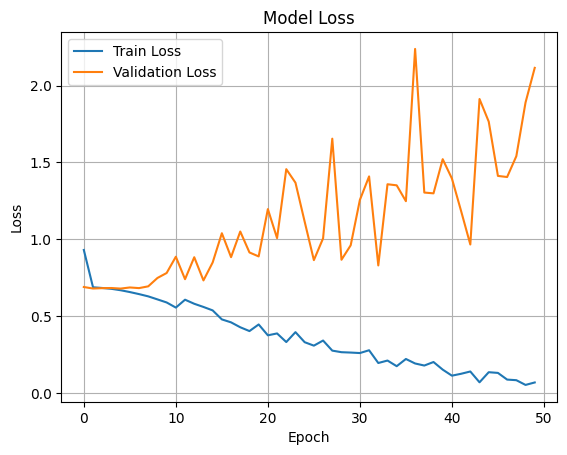

In [16]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [17]:

model.save("model.h5")
